In [12]:
# Upload CSV files
from google.colab import files
import io

print("Please upload your CSV files:")
print("1. tripadvisor_hotel_reviews.csv")
print("2. ai_generated_tripadvisor_reviews_gemma3_4b.csv")

uploaded = files.upload()
print("\n✓ Files uploaded successfully!")

Please upload your CSV files:
1. tripadvisor_hotel_reviews.csv
2. ai_generated_tripadvisor_reviews_gemma3_4b.csv


Saving ai_generated_tripadvisor_reviews_gemma3_4b.csv to ai_generated_tripadvisor_reviews_gemma3_4b (2).csv
Saving tripadvisor_hotel_reviews.csv to tripadvisor_hotel_reviews (2).csv

✓ Files uploaded successfully!


In [13]:
# ============================================================================
# WEEK 1: DATA PREPARATION AND FEATURE EXTRACTION
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
import string
import re
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print("="*70)
print("WEEK 1: DATA PREPARATION & FEATURE EXTRACTION")
print("="*70)

# ============================================================================
# Step 1: Load and prepare datasets
# ============================================================================
print("\nStep 1: Loading datasets...")

# Load human reviews
human_df = pd.read_csv('tripadvisor_hotel_reviews.csv')
human_df['label'] = 0  # 0 = Human
print(f"✓ Loaded {len(human_df)} human reviews")

# Load AI-generated reviews
ai_df = pd.read_csv('ai_generated_tripadvisor_reviews_gemma3_4b.csv')
ai_df['label'] = 1  # 1 = AI
print(f"✓ Loaded {len(ai_df)} AI-generated reviews")

# Combine datasets
df = pd.concat(
    [human_df[['Review', 'label']], ai_df[['Review', 'label']]],
    ignore_index=True
)

print(f"\nTotal dataset size: {len(df)} reviews")
print(f"  Human: {(df['label'] == 0).sum()} reviews")
print(f"  AI:    {(df['label'] == 1).sum()} reviews")

# ============================================================================
# Step 2: Train/Validation/Test Split
# ============================================================================
print("\n" + "="*70)
print("Step 2: Creating train/validation/test splits (60/20/20)")
print("="*70)

# First split: 80% train+val, 20% test
train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

# Second split: 75% train, 25% val (of the 80%, giving 60/20 overall)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,
    random_state=42,
    stratify=train_val_df['label']
)

print(f"\nTrain set: {len(train_df)} samples")
print(f"  Human: {(train_df['label'] == 0).sum()}")
print(f"  AI:    {(train_df['label'] == 1).sum()}")

print(f"\nValidation set: {len(val_df)} samples")
print(f"  Human: {(val_df['label'] == 0).sum()}")
print(f"  AI:    {(val_df['label'] == 1).sum()}")

print(f"\nTest set: {len(test_df)} samples")
print(f"  Human: {(test_df['label'] == 0).sum()}")
print(f"  AI:    {(test_df['label'] == 1).sum()}")

# Verify stratification
print("\nClass balance verification:")
print(f"  Train:      {(train_df['label'] == 1).sum() / len(train_df) * 100:.1f}% AI")
print(f"  Validation: {(val_df['label'] == 1).sum() / len(val_df) * 100:.1f}% AI")
print(f"  Test:       {(test_df['label'] == 1).sum() / len(test_df) * 100:.1f}% AI")

# ============================================================================
# Step 3: Stylometry Feature Extractor
# ============================================================================
print("\n" + "="*70)
print("Step 3: Implementing stylometry feature extractor")
print("="*70)

# Initialize stopwords
stop_words = set(stopwords.words('english'))

def extract_stylometric_features(text):
    """
    Extract 10 stylometric features from text.
    Based on Shah et al. and Li & Zhang's approaches.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return None

    # Tokenization
    try:
        words = word_tokenize(text.lower())
        sentences = sent_tokenize(text)
    except LookupError:
        nltk.download('punkt', quiet=True)
        nltk.download('punkt_tab', quiet=True)
        words = word_tokenize(text.lower())
        sentences = sent_tokenize(text)

    # Filter out punctuation for word-level metrics
    words_no_punct = [w for w in words if w not in string.punctuation]

    if len(words_no_punct) == 0:
        return None

    # 1. Average word length
    avg_word_length = np.mean([len(w) for w in words_no_punct])

    # 2. Type-token ratio (lexical diversity)
    unique_words = set(words_no_punct)
    type_token_ratio = len(unique_words) / len(words_no_punct) if len(words_no_punct) > 0 else 0

    # 3. Hapax ratio (words appearing once)
    word_freq = {}
    for w in words_no_punct:
        word_freq[w] = word_freq.get(w, 0) + 1
    hapax_words = [w for w, count in word_freq.items() if count == 1]
    hapax_ratio = len(hapax_words) / len(unique_words) if len(unique_words) > 0 else 0

    # 4. Stopword ratio
    stopword_count = sum(1 for w in words_no_punct if w in stop_words)
    stopword_ratio = stopword_count / len(words_no_punct) if len(words_no_punct) > 0 else 0

    # 5. Average words per sentence
    avg_words_per_sentence = len(words_no_punct) / len(sentences) if len(sentences) > 0 else 0

    # 6. Average sentence length (characters)
    avg_sentence_length = np.mean([len(s) for s in sentences]) if len(sentences) > 0 else 0

    # 7. Sentence length variance
    sentence_length_variance = np.var([len(s) for s in sentences]) if len(sentences) > 1 else 0

    # 8. Paragraph count
    paragraphs = [p for p in text.split('\n') if p.strip()]
    paragraph_count = len(paragraphs)

    # 9. Period ratio
    period_count = text.count('.')
    period_ratio = period_count / len(text) if len(text) > 0 else 0

    # 10. Capital letter ratio
    capital_count = sum(1 for c in text if c.isupper())
    capital_letter_ratio = capital_count / len(text) if len(text) > 0 else 0

    return {
        'avg_word_length': round(avg_word_length, 3),
        'type_token_ratio': round(type_token_ratio, 3),
        'hapax_ratio': round(hapax_ratio, 3),
        'stopword_ratio': round(stopword_ratio, 3),
        'avg_words_per_sentence': round(avg_words_per_sentence, 3),
        'avg_sentence_length': round(avg_sentence_length, 3),
        'sentence_length_variance': round(sentence_length_variance, 3),
        'paragraph_count': paragraph_count,
        'period_ratio': round(period_ratio, 4),
        'capital_letter_ratio': round(capital_letter_ratio, 4)
    }

print("\n✓ Feature extractor implemented with 10 stylometric features:")
print("  1. avg_word_length")
print("  2. type_token_ratio")
print("  3. hapax_ratio")
print("  4. stopword_ratio")
print("  5. avg_words_per_sentence")
print("  6. avg_sentence_length")
print("  7. sentence_length_variance")
print("  8. paragraph_count")
print("  9. period_ratio")
print("  10. capital_letter_ratio")

# Test on sample review
sample_review = train_df.iloc[0]['Review']
sample_features = extract_stylometric_features(sample_review)
print("\nSample feature extraction:")
print(f"Review: '{sample_review[:80]}...'")
print(f"Features: {sample_features}")

print("\n" + "="*70)
print("WEEK 1 COMPLETE!")
print("="*70)

WEEK 1: DATA PREPARATION & FEATURE EXTRACTION

Step 1: Loading datasets...
✓ Loaded 20491 human reviews
✓ Loaded 10000 AI-generated reviews

Total dataset size: 30491 reviews
  Human: 20491 reviews
  AI:    10000 reviews

Step 2: Creating train/validation/test splits (60/20/20)

Train set: 18294 samples
  Human: 12294
  AI:    6000

Validation set: 6098 samples
  Human: 4098
  AI:    2000

Test set: 6099 samples
  Human: 4099
  AI:    2000

Class balance verification:
  Train:      32.8% AI
  Validation: 32.8% AI
  Test:       32.8% AI

Step 3: Implementing stylometry feature extractor

✓ Feature extractor implemented with 10 stylometric features:
  1. avg_word_length
  2. type_token_ratio
  3. hapax_ratio
  4. stopword_ratio
  5. avg_words_per_sentence
  6. avg_sentence_length
  7. sentence_length_variance
  8. paragraph_count
  9. period_ratio
  10. capital_letter_ratio

Sample feature extraction:
Review: 'Okay, here’s a TripAdvisor-style hotel review following your guidelines: Hones

In [14]:
%pip install -q -U langchain langchain-openai langchain-classic openai

In [15]:
# ============================================================================
# WEEK 2: BASELINE LLM DETECTOR
# ============================================================================

from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_classic.chains import LLMChain
from langchain_core.tools import tool
from pydantic import BaseModel, Field
import json
from typing import Literal
import time
import pickle
import re
import numpy as np
from tqdm import tqdm
from google.colab import userdata  # For accessing secrets
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

print("\n" + "=" * 70)
print("WEEK 2: BASELINE SINGLE-PASS LLM DETECTOR")
print("Task: Implement prompting-only baseline (Alshammari & Rao approach)")
print("=" * 70)

# ============================================================================
# Step 1: Define output schema
# ============================================================================

print("\nStep 1: Defining baseline output schema...")

class BaselineDetectionResult(BaseModel):
    """Structured output for baseline LLM detector"""
    prediction: Literal["AI", "Human"] = Field(
        description="Classification: 'AI' if AI-generated, 'Human' if human-written"
    )
    ai_probability: int = Field(
        description="Estimated probability from 0-100 that the review is AI-generated",
        ge=0,
        le=100
    )
    human_probability: int = Field(
        description="Estimated probability from 0-100 that the review is human-written",
        ge=0,
        le=100
    )
    reasoning: str = Field(
        description="Step-by-step explanation of the decision"
    )

print("✓ Pydantic schema created")

# ============================================================================
# Step 2: Design few-shot prompt
# ============================================================================

print("\nStep 2: Designing few-shot prompt with chain-of-thought...")

# Few-shot examples
human_examples = [
    "stayed here last week. rooms ok but wifi terrible. breakfast was meh. location good though",
    "nice hotel but overpriced for what you get. staff friendly. would not return",
    "great stay! clean room, comfortable bed. close to attractions. highly recommend"
]

ai_examples = [
    "This hotel exceeded all expectations! The staff went above and beyond to ensure our stay was memorable. The amenities were first-class.",
    "We had a wonderful experience at this establishment. The location is convenient, the rooms are well-appointed, and the service is exceptional.",
    "Our stay was absolutely perfect. From the moment we arrived, we felt welcomed. The attention to detail was remarkable."
]

baseline_prompt = """You are an expert at detecting AI-generated text. Your task is to analyze hotel reviews and determine if they were written by a human or generated by AI.

Here are some examples:

HUMAN REVIEW EXAMPLES:
1. "{human_1}" -> This is HUMAN because: casual language, informal grammar, specific complaints, no excessive positivity
2. "{human_2}" -> This is HUMAN because: mixed opinion, terse style, personal judgment
3. "{human_3}" -> This is HUMAN because: enthusiastic but natural, specific details, grammatical simplicity

AI REVIEW EXAMPLES:
1. "{ai_1}" -> This is AI because: overly formal, excessive enthusiasm, generic praise, perfect grammar
2. "{ai_2}" -> This is AI because: very structured, formal vocabulary ("establishment", "well-appointed"), lacks specificity
3. "{ai_3}" -> This is AI because: consistent positive tone, generic details, formal phrasing

Now analyze this review carefully.

REVIEW TO ANALYZE:
"{review_text}"

INSTRUCTIONS:
1. Analyze the writing style (formal vs casual, grammar, word choice)
2. Examine emotional tone (consistent vs mixed, genuine vs generic)
3. Check for specificity (concrete details vs vague descriptions)
4. Make your classification and explain your reasoning
5. Return JSON only
6. Do not use markdown fences
7. Do not add any text before or after the JSON
8. The prediction field must be exactly one of these two strings only:
   - "AI"
   - "Human"
9. Do not use labels like:
   - "AI-generated"
   - "Human-written"
   - "Likely AI"
   - "Likely Human"
10. Provide both ai_probability and human_probability as integers from 0-100
11. ai_probability + human_probability must equal 100
12. If the review is ambiguous, keep the probabilities closer together
13. Do not use 0 or 100 unless the evidence is overwhelmingly one-sided

Respond in this exact JSON format:
{{
    "prediction": "AI",
    "ai_probability": 78,
    "human_probability": 22,
    "reasoning": "The writing style is formal and polished, the tone is consistently positive, and the details are somewhat generic, which makes it more likely AI-generated."
}}
"""

prompt_template = PromptTemplate(
    input_variables=["review_text"],
    template=baseline_prompt,
    partial_variables={
        "human_1": human_examples[0],
        "human_2": human_examples[1],
        "human_3": human_examples[2],
        "ai_1": ai_examples[0],
        "ai_2": ai_examples[1],
        "ai_3": ai_examples[2],
    }
)

print("✓ Few-shot prompt with chain-of-thought designed")
print(" - 3 human examples")
print(" - 3 AI examples")
print(" - Step-by-step reasoning instructions")
print(" - Structured JSON output")

# ============================================================================
# Step 3: Initialize LLM and create chain
# ============================================================================

print("\nStep 3: Initializing LLM and creating baseline chain...")

openai_api_key = userdata.get("OPENAI_API_KEY")
if not openai_api_key:
    raise ValueError("OPENAI_API_KEY not found in Colab secrets.")

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=openai_api_key
)

print("✓ LLM initialized with API key from secrets")
print("  Model: gpt-4o-mini")
print("  Temperature: 0 (deterministic)")

baseline_chain = LLMChain(
    llm=llm,
    prompt=prompt_template,
    verbose=False
)

print("✓ Baseline chain created")

# ============================================================================
# Step 4: Test baseline on sample reviews
# ============================================================================

print("\n" + "=" * 70)
print("BASELINE TESTING")
print("=" * 70)

def clean_json_response(text):
    """Remove markdown code fences and extract the first JSON object."""
    if text is None:
        return None
    text = text.strip()

    # Remove ```json ... ``` or ``` ... ```
    text = re.sub(r"^```(?:json)?\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    # Extract first JSON object if extra text appears
    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if match:
        return match.group(0).strip()

    return text

def normalize_prediction(pred):
    """Map common LLM label variants to exact labels: AI / Human."""
    if pred is None:
        return None

    pred = str(pred).strip().lower()

    ai_variants = {
        "ai",
        "ai-generated",
        "generated by ai",
        "generated",
        "likely ai",
        "artificial intelligence",
        "artificially generated",
    }
    human_variants = {
        "human",
        "human-written",
        "written by a human",
        "likely human",
        "person",
        "person-written",
    }

    if pred in ai_variants:
        return "AI"
    if pred in human_variants:
        return "Human"
    if "ai" in pred and "human" not in pred:
        return "AI"
    if "human" in pred:
        return "Human"

    return None

def parse_probability_value(x):
    """Parse integers, floats, or strings like '78%' into an int."""
    if x is None:
        return None

    if isinstance(x, (int, float, np.integer, np.floating)):
        return int(round(float(x)))

    s = str(x).strip().replace("%", "")
    match = re.search(r"-?\d+(\.\d+)?", s)
    if match:
        return int(round(float(match.group())))

    return None

def normalize_probabilities(ai_prob, human_prob, prediction):
    """Clean and normalize probabilities so they are valid and sum to 100."""
    ai_prob = parse_probability_value(ai_prob)
    human_prob = parse_probability_value(human_prob)

    if ai_prob is None and human_prob is None:
        if prediction == "AI":
            return 65, 35
        elif prediction == "Human":
            return 35, 65
        return 50, 50

    if ai_prob is None and human_prob is not None:
        human_prob = max(0, min(100, human_prob))
        ai_prob = 100 - human_prob

    if human_prob is None and ai_prob is not None:
        ai_prob = max(0, min(100, ai_prob))
        human_prob = 100 - ai_prob

    ai_prob = max(0, min(100, ai_prob))
    human_prob = max(0, min(100, human_prob))

    total = ai_prob + human_prob
    if total == 0:
        return 50, 50

    if total != 100:
        ai_prob = int(round(ai_prob * 100 / total))
        human_prob = 100 - ai_prob

    return ai_prob, human_prob

def derive_confidence(ai_prob, human_prob):
    """Confidence is the larger of the two class probabilities."""
    return max(ai_prob, human_prob)

def run_baseline_detection(review_text, debug=False):
    """Run baseline LLM detector on a single review."""
    try:
        result = baseline_chain.predict(review_text=review_text)
        cleaned = clean_json_response(result)
        parsed = json.loads(cleaned)

        raw_prediction = parsed.get("prediction", None)
        normalized_prediction = normalize_prediction(raw_prediction)

        if normalized_prediction is None:
            if debug:
                print("\nRaw model output:")
                print(result)
                print("\nParsed JSON:")
                print(parsed)
            raise ValueError("Invalid prediction value returned.")

        ai_prob = parsed.get("ai_probability", None)
        human_prob = parsed.get("human_probability", None)
        ai_prob, human_prob = normalize_probabilities(
            ai_prob, human_prob, normalized_prediction
        )

        confidence = derive_confidence(ai_prob, human_prob)
        reasoning = str(parsed.get("reasoning", "")).strip()

        return {
            "prediction": normalized_prediction,
            "confidence": confidence,
            "ai_probability": ai_prob,
            "human_probability": human_prob,
            "reasoning": reasoning,
            "raw_prediction": raw_prediction,
        }

    except Exception as e:
        if debug:
            print(f"Error: {e}")
        return None

print("\nTest 1: Known Human Review")
print("-" * 70)

human_test = test_df[test_df["label"] == 0].iloc[0]["Review"]
print(f'Review: "{human_test[:100]}..."')

result = run_baseline_detection(human_test, debug=True)
if result:
    print(f"\nPrediction: {result['prediction']}")
    print(f"AI Probability: {result['ai_probability']}/100")
    print(f"Human Probability: {result['human_probability']}/100")
    print(f"Confidence: {result['confidence']}/100")
    print(f"Reasoning: {result['reasoning'][:200]}...")

print("\n\nTest 2: Known AI Review")
print("-" * 70)

ai_test = test_df[test_df["label"] == 1].iloc[0]["Review"]
print(f'Review: "{ai_test[:100]}..."')

result = run_baseline_detection(ai_test, debug=True)
if result:
    print(f"\nPrediction: {result['prediction']}")
    print(f"AI Probability: {result['ai_probability']}/100")
    print(f"Human Probability: {result['human_probability']}/100")
    print(f"Confidence: {result['confidence']}/100")
    print(f"Reasoning: {result['reasoning'][:200]}...")

# ============================================================================
# Step 5: Evaluate baseline on test set
# ============================================================================

print("\n\n" + "=" * 70)
print("BASELINE EVALUATION ON TEST SET")
print("=" * 70)

# Take a sample of test set for evaluation to manage API costs
sample_n = min(100, len(test_df))
test_sample = test_df.sample(n=sample_n, random_state=42)

print(f"\nEvaluating on {len(test_sample)} test reviews...")
print("(Using sample to manage API costs. For full eval, use entire test_df)")

baseline_predictions = []
baseline_confidences = []
baseline_ai_probs = []
baseline_human_probs = []
baseline_correct = []
invalid_outputs = []

print("\nProcessing reviews...")

for idx, (_, row) in enumerate(tqdm(test_sample.iterrows(), total=len(test_sample))):
    review = row["Review"]
    true_label = "AI" if row["label"] == 1 else "Human"

    result = run_baseline_detection(review, debug=False)

    if result:
        pred = result["prediction"]
        conf = result["confidence"]

        baseline_predictions.append(pred)
        baseline_confidences.append(conf)
        baseline_ai_probs.append(result["ai_probability"])
        baseline_human_probs.append(result["human_probability"])
        baseline_correct.append(pred == true_label)
    else:
        baseline_predictions.append("Human")  # fallback baseline
        baseline_confidences.append(50)
        baseline_ai_probs.append(50)
        baseline_human_probs.append(50)
        baseline_correct.append(False)
        invalid_outputs.append(idx)

    time.sleep(0.5)

# Calculate metrics
y_true_binary = [1 if row_label == 1 else 0 for row_label in test_sample["label"]]
y_pred_binary = [1 if p == "AI" else 0 for p in baseline_predictions]

baseline_accuracy = accuracy_score(y_true_binary, y_pred_binary)
baseline_precision, baseline_recall, baseline_f1, _ = precision_recall_fscore_support(
    y_true_binary,
    y_pred_binary,
    average="binary",
    zero_division=0
)

print("\n" + "=" * 70)
print("BASELINE RESULTS")
print("=" * 70)

print(f"\nAccuracy: {baseline_accuracy:.3f}")
print(f"Precision: {baseline_precision:.3f}")
print(f"Recall: {baseline_recall:.3f}")
print(f"F1-Score: {baseline_f1:.3f}")

cm = confusion_matrix(y_true_binary, y_pred_binary)
print("\nConfusion Matrix:")
print("              Predicted Human  Predicted AI")
print(f"True Human    {cm[0,0]:5d}            {cm[0,1]:5d}")
print(f"True AI       {cm[1,0]:5d}            {cm[1,1]:5d}")

avg_confidence = np.mean(baseline_confidences)
avg_ai_prob = np.mean(baseline_ai_probs)
avg_human_prob = np.mean(baseline_human_probs)

print(f"\nAverage Confidence: {avg_confidence:.1f}/100")
print(f"Average AI Probability: {avg_ai_prob:.1f}/100")
print(f"Average Human Probability: {avg_human_prob:.1f}/100")
print(f"Failed parses handled by fallback: {len(invalid_outputs)}")

# ============================================================================
# Step 6: LangChain tool wrapper for feature extractor
# ============================================================================

print("\n\n" + "=" * 70)
print("LANGCHAIN TOOL WRAPPER FOR FEATURE EXTRACTOR")
print("=" * 70)

@tool
def extract_features_tool(review_text: str) -> dict:
    """
    Extract stylometric features from a hotel review.

    Args:
        review_text: The review text to analyze

    Returns:
        Dictionary containing 10 stylometric features
    """
    features = extract_stylometric_features(review_text)
    return features if features else {}

print("\n✓ Feature extraction tool created")
print(f"  Tool name: {extract_features_tool.name}")
print(f"  Tool description: {extract_features_tool.description}")

# Test the tool
test_review = "Great hotel! Clean rooms and friendly staff."
test_features = extract_features_tool.run(test_review)

print("\nTest extraction:")
print(f'  Input: "{test_review}"')
print(f"  Output: {test_features}")

# Save baseline results for comparison in Week 3
baseline_results = {
    "predictions": baseline_predictions,
    "confidences": baseline_confidences,
    "ai_probabilities": baseline_ai_probs,
    "human_probabilities": baseline_human_probs,
    "accuracy": baseline_accuracy,
    "precision": baseline_precision,
    "recall": baseline_recall,
    "f1": baseline_f1,
    "confusion_matrix": cm,
    "failed_parse_count": len(invalid_outputs),
}

with open("baseline_results.pkl", "wb") as f:
    pickle.dump(baseline_results, f)

print("\n✓ Baseline results saved to: baseline_results.pkl")

print("\n" + "=" * 70)
print("WEEK 2 COMPLETE!")
print("=" * 70)

print("\nKey Deliverables:")
print("1. ✓ Baseline LLM detector with few-shot prompting")
print("2. ✓ Chain-of-thought reasoning implemented")
print("3. ✓ Baseline evaluation on test sample completed")
print("4. ✓ Feature extraction tool wrapper created")
print(f"\nBaseline Performance: {baseline_accuracy:.1%} accuracy")


WEEK 2: BASELINE SINGLE-PASS LLM DETECTOR
Task: Implement prompting-only baseline (Alshammari & Rao approach)

Step 1: Defining baseline output schema...
✓ Pydantic schema created

Step 2: Designing few-shot prompt with chain-of-thought...
✓ Few-shot prompt with chain-of-thought designed
 - 3 human examples
 - 3 AI examples
 - Step-by-step reasoning instructions
 - Structured JSON output

Step 3: Initializing LLM and creating baseline chain...
✓ LLM initialized with API key from secrets
  Model: gpt-4o-mini
  Temperature: 0 (deterministic)
✓ Baseline chain created

BASELINE TESTING

Test 1: Known Human Review
----------------------------------------------------------------------
Review: "really really arrived aston ubud waved security barriers stopped checked, liberty drag suitcases ste..."

Prediction: Human
AI Probability: 30/100
Human Probability: 70/100
Confidence: 70/100
Reasoning: The writing style is casual and somewhat disjointed, with informal grammar and a mix of specific co

100%|██████████| 100/100 [03:40<00:00,  2.20s/it]


BASELINE RESULTS

Accuracy: 0.740
Precision: 0.583
Recall: 0.250
F1-Score: 0.350

Confusion Matrix:
              Predicted Human  Predicted AI
True Human       67                5
True AI          21                7

Average Confidence: 70.7/100
Average AI Probability: 35.4/100
Average Human Probability: 64.7/100
Failed parses handled by fallback: 0


LANGCHAIN TOOL WRAPPER FOR FEATURE EXTRACTOR

✓ Feature extraction tool created
  Tool name: extract_features_tool
  Tool description: Extract stylometric features from a hotel review.

Args:
    review_text: The review text to analyze

Returns:
    Dictionary containing 10 stylometric features

Test extraction:
  Input: "Great hotel! Clean rooms and friendly staff."
  Output: {'avg_word_length': np.float64(5.143), 'type_token_ratio': 1.0, 'hapax_ratio': 1.0, 'stopword_ratio': 0.143, 'avg_words_per_sentence': 3.5, 'avg_sentence_length': np.float64(21.5), 'sentence_length_variance': np.float64(90.25), 'paragraph_count': 1, 'period_ratio

WEEK 3: CLASSIFIER TRAINING + TEMPERATURE SCALING + CLASSIFIER TOOL
Tasks:
  Wendy: Train Logistic Regression and Random Forest on stylometry features
  Wency: Implement temperature scaling calibration using validation set
  Yujia: Create custom tool wrapper for classifier and test tool integration

Sanity check passed:
  Train rows: 18294
  Validation rows: 6098
  Test rows: 6099

Week 2 baseline loaded successfully:
  Accuracy:  0.740
  Precision: 0.583
  Recall:    0.250
  F1:        0.350

STEP 1: NORMALIZE REVIEW TEXT BEFORE FEATURE EXTRACTION
Detected generator-style boilerplate prefixes:
  AI train: 1712
  AI val:   632
  AI test:  589

STEP 2: BUILD WEEK 3 FEATURE SET FROM WEEK 1 EXTRACTOR

Week 1 raw sample:
  Okay, here’s a TripAdvisor-style hotel review following your guidelines: Honestly, the location of the Grandview Hotel i...

Normalized sample:
  Honestly, the location of the Grandview Hotel is the *only* reason I'm giving it three stars. It's absolutely perfect – ...



test features: 100%|██████████| 6099/6099 [00:10<00:00, 583.08it/s]



Feature extraction complete.
  Number of Week 3 stylometric features: 14
  Feature names: ['avg_word_length', 'type_token_ratio', 'hapax_ratio', 'stopword_ratio', 'avg_words_per_sentence', 'avg_sentence_length', 'sentence_length_variance', 'paragraph_count', 'period_ratio', 'capital_letter_ratio', 'comma_ratio', 'exclamation_ratio', 'question_ratio', 'long_word_ratio']

STEP 4: TRAIN LOGISTIC REGRESSION AND RANDOM FOREST

----------------------------------------------------------------------
LOGISTIC REGRESSION - VALIDATION
----------------------------------------------------------------------
Accuracy:  0.9989
Precision: 0.9965
Recall:    1.0000
F1-Score:  0.9983
Train Time: 0.40 seconds

----------------------------------------------------------------------
LOGISTIC REGRESSION - TEST
----------------------------------------------------------------------
Accuracy:  0.9985
Precision: 0.9955
Recall:    1.0000
F1-Score:  0.9978

----------------------------------------------------------

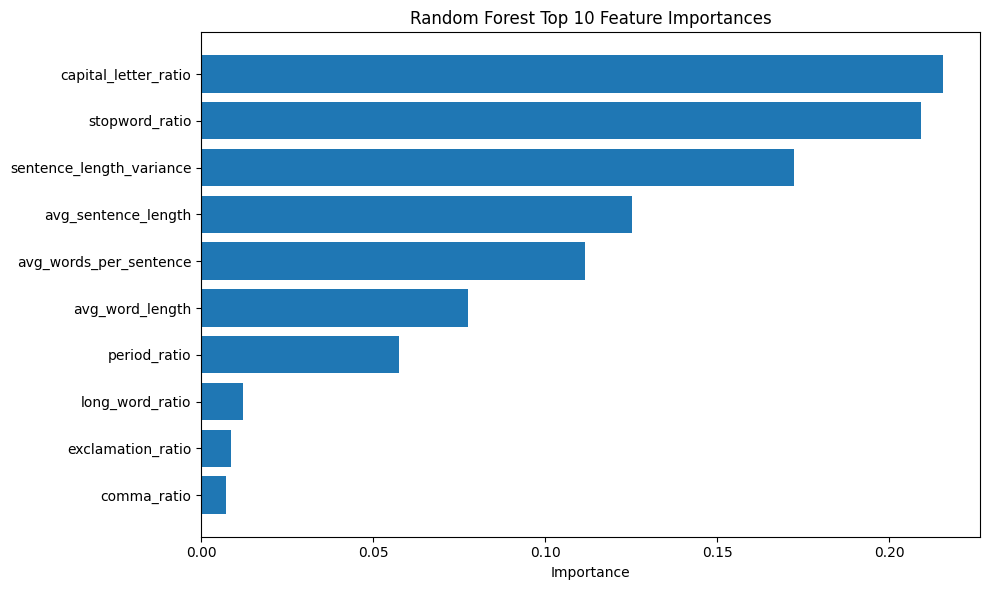


STEP 6: TEMPERATURE SCALING CALIBRATION USING VALIDATION SET ONLY

Optimal temperature for Logistic Regression: 0.6806
Optimal temperature for Random Forest:       0.2377

Calibration summary:
         Classifier  Temperature  Brier Before  Brier After  LogLoss Before  LogLoss After
Logistic Regression     0.680615      0.000942 9.412992e-04        0.004496   3.195260e-03
      Random Forest     0.237723      0.000005 3.631650e-12        0.000120   4.608653e-08

----------------------------------------------------------------------
LOGISTIC REGRESSION - TEST AFTER CALIBRATION
----------------------------------------------------------------------
Accuracy:  0.9985
Precision: 0.9955
Recall:    1.0000
F1-Score:  0.9978

----------------------------------------------------------------------
RANDOM FOREST - TEST AFTER CALIBRATION
----------------------------------------------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

Selected final cla

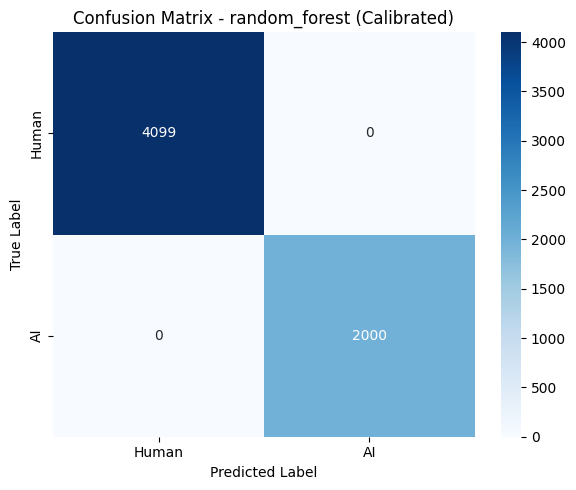

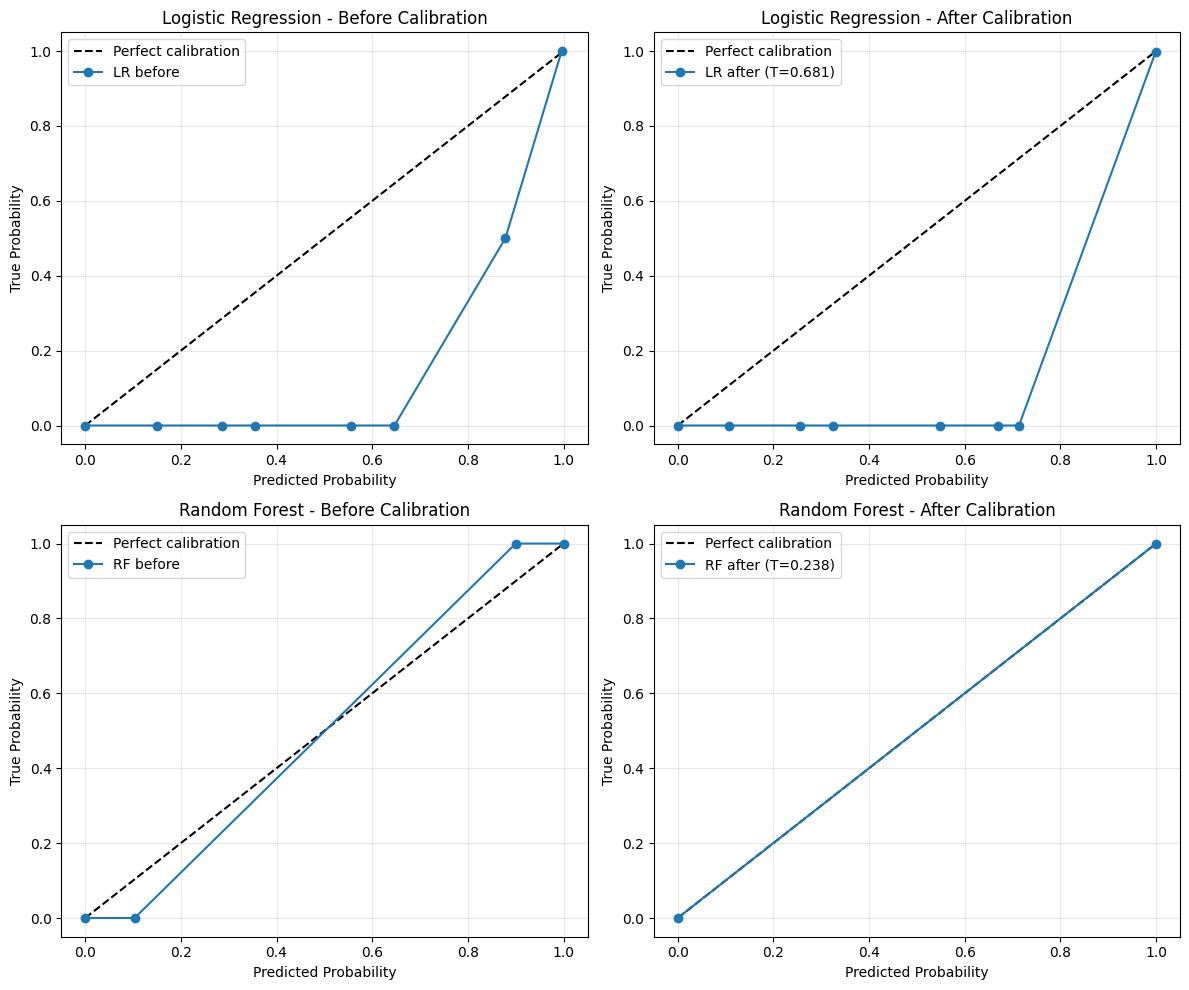

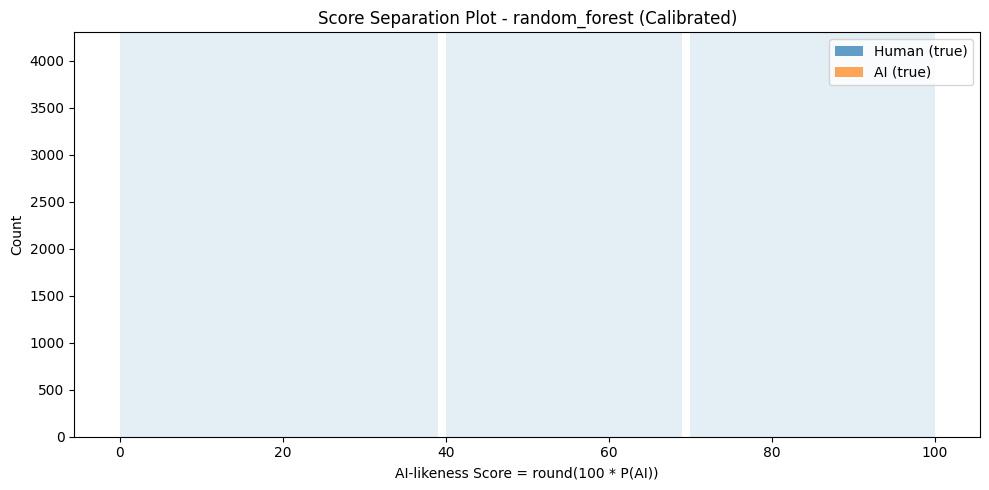


STEP 9: COMPARE PROPOSED SYSTEM AGAINST WEEK 2 BASELINE
Week 2 baseline F1: 0.3500
Week 3 selected calibrated F1: 1.0000
Absolute F1 improvement: +0.6500
Meets proposal success criterion (>= 0.05 F1 improvement): True

STEP 10: CLASSIFIER TOOL WRAPPER + INTEGRATION TESTS

Classifier tools created:
  Selected tool: classify_review_with_selected_model
  LR tool:       classify_review_with_logistic_regression
  RF tool:       classify_review_with_random_forest

Selected classifier tool tests:

----------------------------------------------------------------------
Sample 1 (Human-like)
----------------------------------------------------------------------
Text: stayed here last week. rooms ok but wifi terrible. breakfast was meh. location good though. would return if price drops
{
  "review_text": "stayed here last week. rooms ok but wifi terrible. breakfast was meh. location good though. would return if price drops",
  "model_used": "random_forest",
  "calibrated": true,
  "ai_probabilit

In [16]:
# ============================================================================
# WEEK 3: TRAIN CLASSIFIERS + CALIBRATE + BUILD CLASSIFIER TOOL WRAPPER
# ============================================================================

import os
import re
import json
import time
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from scipy.optimize import minimize

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    brier_score_loss,
    log_loss
)
from sklearn.calibration import calibration_curve

import nltk
from nltk.tokenize import word_tokenize

try:
    from langchain_core.tools import tool
except Exception:
    from langchain.tools import tool

from pydantic import BaseModel, Field
from typing import Dict

# Make sure tokenizer is available even if the runtime restarted
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

print("=" * 80)
print("WEEK 3: CLASSIFIER TRAINING + TEMPERATURE SCALING + CLASSIFIER TOOL")
print("Tasks:")
print("  Wendy: Train Logistic Regression and Random Forest on stylometry features")
print("  Wency: Implement temperature scaling calibration using validation set")
print("  Yujia: Create custom tool wrapper for classifier and test tool integration")
print("=" * 80)

# ----------------------------------------------------------------------------
# 0) Sanity checks
# ----------------------------------------------------------------------------
required_objects = [
    "train_df", "val_df", "test_df",
    "extract_stylometric_features"
]
missing_objects = [obj for obj in required_objects if obj not in globals()]
if missing_objects:
    raise ValueError(
        f"Missing required Week 1 / Week 2 objects: {missing_objects}. "
        f"Run your Week 1 and Week 2 cells first."
    )

print("\nSanity check passed:")
print(f"  Train rows: {len(train_df)}")
print(f"  Validation rows: {len(val_df)}")
print(f"  Test rows: {len(test_df)}")

# Load Week 2 baseline results if available
baseline_loaded = False
baseline_accuracy = baseline_precision = baseline_recall = baseline_f1 = None

if "baseline_results" in globals():
    try:
        baseline_accuracy = baseline_results["accuracy"]
        baseline_precision = baseline_results["precision"]
        baseline_recall = baseline_results["recall"]
        baseline_f1 = baseline_results["f1"]
        baseline_loaded = True
    except Exception:
        baseline_loaded = False

if (not baseline_loaded) and os.path.exists("baseline_results.pkl"):
    try:
        with open("baseline_results.pkl", "rb") as f:
            baseline_results = pickle.load(f)
        baseline_accuracy = baseline_results["accuracy"]
        baseline_precision = baseline_results["precision"]
        baseline_recall = baseline_results["recall"]
        baseline_f1 = baseline_results["f1"]
        baseline_loaded = True
    except Exception:
        baseline_loaded = False

if baseline_loaded:
    print("\nWeek 2 baseline loaded successfully:")
    print(f"  Accuracy:  {baseline_accuracy:.3f}")
    print(f"  Precision: {baseline_precision:.3f}")
    print(f"  Recall:    {baseline_recall:.3f}")
    print(f"  F1:        {baseline_f1:.3f}")
else:
    print("\nWeek 2 baseline_results not found. Week 3 will still run, but baseline comparison will be skipped.")

# ----------------------------------------------------------------------------
# 1) Normalize review text
# Removes common generator boilerplate seen in the Week 1 sample output
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 1: NORMALIZE REVIEW TEXT BEFORE FEATURE EXTRACTION")
print("=" * 80)

GEN_PREFIX_PATTERNS = [
    r"^\s*okay[,!\s]*here[’']?s\s+a\s+tripadvisor-style\s+hotel\s+review[^:]*:\s*",
    r"^\s*sure[,!\s]*here[’']?s\s+a\s+tripadvisor-style\s+hotel\s+review[^:]*:\s*",
    r"^\s*here[’']?s\s+a\s+tripadvisor-style\s+hotel\s+review[^:]*:\s*",
    r"^\s*tripadvisor-style\s+hotel\s+review[^:]*:\s*",
    r"^\s*hotel\s+review\s*:\s*",
    r"^\s*review\s*:\s*",
]

def normalize_review_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.replace("’", "'").replace("“", '"').replace("”", '"').strip()

    for pattern in GEN_PREFIX_PATTERNS:
        text = re.sub(pattern, "", text, flags=re.IGNORECASE)

    text = re.sub(r"\s+", " ", text).strip()
    return text

def count_generator_prefixes(series):
    count = 0
    for x in series.fillna("").astype(str):
        x = x.strip()
        matched = False
        for pattern in GEN_PREFIX_PATTERNS:
            if re.search(pattern, x, flags=re.IGNORECASE):
                matched = True
                break
        if matched:
            count += 1
    return count

ai_prefix_train = count_generator_prefixes(train_df[train_df["label"] == 1]["Review"])
ai_prefix_val = count_generator_prefixes(val_df[val_df["label"] == 1]["Review"])
ai_prefix_test = count_generator_prefixes(test_df[test_df["label"] == 1]["Review"])

print("Detected generator-style boilerplate prefixes:")
print(f"  AI train: {ai_prefix_train}")
print(f"  AI val:   {ai_prefix_val}")
print(f"  AI test:  {ai_prefix_test}")

# ----------------------------------------------------------------------------
# 2) Extend Week 1 stylometry from 10 features to 14 features
# Preserves Week 1 features and adds more punctuation and lexical features
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 2: BUILD WEEK 3 FEATURE SET FROM WEEK 1 EXTRACTOR")
print("=" * 80)

def extract_week3_features(text):
    clean_text = normalize_review_text(text)

    base = extract_stylometric_features(clean_text)
    if base is None:
        return None

    try:
        words = word_tokenize(clean_text.lower())
    except Exception:
        words = re.findall(r"\b\w+\b", clean_text.lower())

    words_no_punct = [w for w in words if re.search(r"[a-zA-Z0-9]", w)]

    comma_ratio = clean_text.count(",") / len(clean_text) if len(clean_text) > 0 else 0
    exclamation_ratio = clean_text.count("!") / len(clean_text) if len(clean_text) > 0 else 0
    question_ratio = clean_text.count("?") / len(clean_text) if len(clean_text) > 0 else 0
    long_word_ratio = (
        sum(1 for w in words_no_punct if len(w) >= 7) / len(words_no_punct)
        if len(words_no_punct) > 0 else 0
    )

    base.update({
        "comma_ratio": round(comma_ratio, 4),
        "exclamation_ratio": round(exclamation_ratio, 4),
        "question_ratio": round(question_ratio, 4),
        "long_word_ratio": round(long_word_ratio, 4),
    })

    clean_base = {}
    for k, v in base.items():
        if isinstance(v, (np.floating, np.integer)):
            clean_base[k] = float(v)
        else:
            clean_base[k] = v

    return clean_base

sample_review_raw = train_df.iloc[0]["Review"]
sample_review_clean = normalize_review_text(sample_review_raw)
sample_features_week3 = extract_week3_features(sample_review_raw)

print("\nWeek 1 raw sample:")
print(f"  {sample_review_raw[:120]}...")
print("\nNormalized sample:")
print(f"  {sample_review_clean[:120]}...")
print("\nWeek 3 feature set implemented with 14 features:")
print(sorted(sample_features_week3.keys()))
print(f"\nSample Week 3 features: {sample_features_week3}")

# ----------------------------------------------------------------------------
# 3) Extract features for train / val / test
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 3: EXTRACT FEATURES FOR TRAIN / VALIDATION / TEST")
print("=" * 80)

def extract_features_for_dataset(df_in, dataset_name):
    features_list = []
    for review in tqdm(df_in["Review"].fillna("").astype(str).values, desc=f"{dataset_name} features"):
        feats = extract_week3_features(review)
        if feats is None:
            feats = {}
        features_list.append(feats)
    return pd.DataFrame(features_list).fillna(0)

train_features = extract_features_for_dataset(train_df, "train")
val_features = extract_features_for_dataset(val_df, "validation")
test_features = extract_features_for_dataset(test_df, "test")

feature_cols = train_features.columns.tolist()
val_features = val_features.reindex(columns=feature_cols, fill_value=0)
test_features = test_features.reindex(columns=feature_cols, fill_value=0)

X_train = train_features.values
y_train = train_df["label"].values

X_val = val_features.values
y_val = val_df["label"].values

X_test = test_features.values
y_test = test_df["label"].values

print("\nFeature extraction complete.")
print(f"  Number of Week 3 stylometric features: {len(feature_cols)}")
print(f"  Feature names: {feature_cols}")

# ----------------------------------------------------------------------------
# 4) Train models
# Uses class weights because the split preserves the original imbalance
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 4: TRAIN LOGISTIC REGRESSION AND RANDOM FOREST")
print("=" * 80)

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)
    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": cm
    }

def print_metrics(title, metrics, train_time=None):
    print("\n" + "-" * 70)
    print(title)
    print("-" * 70)
    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1-Score:  {metrics['f1']:.4f}")
    if train_time is not None:
        print(f"Train Time: {train_time:.2f} seconds")

# Logistic Regression
start = time.time()
lr_clf = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced",
    solver="lbfgs"
)
lr_clf.fit(X_train, y_train)
lr_train_time = time.time() - start

# Random Forest
start = time.time()
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)
rf_train_time = time.time() - start

# Raw predictions and probabilities
lr_pred_val = lr_clf.predict(X_val)
lr_pred_test = lr_clf.predict(X_test)
lr_proba_val = lr_clf.predict_proba(X_val)[:, 1]
lr_proba_test = lr_clf.predict_proba(X_test)[:, 1]

rf_pred_val = rf_clf.predict(X_val)
rf_pred_test = rf_clf.predict(X_test)
rf_proba_val = rf_clf.predict_proba(X_val)[:, 1]
rf_proba_test = rf_clf.predict_proba(X_test)[:, 1]

lr_val_metrics = compute_metrics(y_val, lr_pred_val)
lr_test_metrics = compute_metrics(y_test, lr_pred_test)

rf_val_metrics = compute_metrics(y_val, rf_pred_val)
rf_test_metrics = compute_metrics(y_test, rf_pred_test)

print_metrics("LOGISTIC REGRESSION - VALIDATION", lr_val_metrics, lr_train_time)
print_metrics("LOGISTIC REGRESSION - TEST", lr_test_metrics)

print_metrics("RANDOM FOREST - VALIDATION", rf_val_metrics, rf_train_time)
print_metrics("RANDOM FOREST - TEST", rf_test_metrics)

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "LR Validation": [
        lr_val_metrics["accuracy"], lr_val_metrics["precision"],
        lr_val_metrics["recall"], lr_val_metrics["f1"]
    ],
    "RF Validation": [
        rf_val_metrics["accuracy"], rf_val_metrics["precision"],
        rf_val_metrics["recall"], rf_val_metrics["f1"]
    ],
    "LR Test": [
        lr_test_metrics["accuracy"], lr_test_metrics["precision"],
        lr_test_metrics["recall"], lr_test_metrics["f1"]
    ],
    "RF Test": [
        rf_test_metrics["accuracy"], rf_test_metrics["precision"],
        rf_test_metrics["recall"], rf_test_metrics["f1"]
    ]
})

print("\nValidation/Test comparison table:")
print(comparison_df.to_string(index=False))

# ----------------------------------------------------------------------------
# 5) Feature importance
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 5: FEATURE IMPORTANCE")
print("=" * 80)

def get_importance_df(model, feature_names):
    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_
    else:
        importance = np.abs(model.coef_[0])

    return pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    }).sort_values("importance", ascending=False).reset_index(drop=True)

lr_importance_df = get_importance_df(lr_clf, feature_cols)
rf_importance_df = get_importance_df(rf_clf, feature_cols)

print("\nTop 5 Logistic Regression features:")
print(lr_importance_df.head(5).to_string(index=False))

print("\nTop 5 Random Forest features:")
print(rf_importance_df.head(5).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(
    rf_importance_df.head(10)["feature"][::-1],
    rf_importance_df.head(10)["importance"][::-1]
)
plt.xlabel("Importance")
plt.title("Random Forest Top 10 Feature Importances")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 6) Temperature scaling using validation set only
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 6: TEMPERATURE SCALING CALIBRATION USING VALIDATION SET ONLY")
print("=" * 80)

class TemperatureScaler:
    def __init__(self):
        self.temperature = 1.0

    def _apply_temperature(self, probs, T):
        probs = np.asarray(probs)
        probs = np.clip(probs, 1e-8, 1 - 1e-8)
        logits = np.log(probs / (1 - probs))
        scaled_logits = logits / T
        scaled_probs = 1 / (1 + np.exp(-scaled_logits))
        return np.clip(scaled_probs, 1e-8, 1 - 1e-8)

    def fit(self, probs, y_true):
        probs = np.asarray(probs)
        y_true = np.asarray(y_true)

        def objective(x):
            T = x[0]
            scaled = self._apply_temperature(probs, T)
            return log_loss(y_true, scaled)

        result = minimize(
            objective,
            x0=np.array([1.0]),
            bounds=[(0.05, 10.0)],
            method="L-BFGS-B"
        )
        self.temperature = float(result.x[0])
        return self

    def predict_proba(self, probs):
        return self._apply_temperature(probs, self.temperature)

lr_temp_scaler = TemperatureScaler().fit(lr_proba_val, y_val)
rf_temp_scaler = TemperatureScaler().fit(rf_proba_val, y_val)

print(f"\nOptimal temperature for Logistic Regression: {lr_temp_scaler.temperature:.4f}")
print(f"Optimal temperature for Random Forest:       {rf_temp_scaler.temperature:.4f}")

# Apply calibration to test probabilities
lr_proba_test_cal = lr_temp_scaler.predict_proba(lr_proba_test)
rf_proba_test_cal = rf_temp_scaler.predict_proba(rf_proba_test)

lr_pred_test_cal = (lr_proba_test_cal >= 0.5).astype(int)
rf_pred_test_cal = (rf_proba_test_cal >= 0.5).astype(int)

lr_test_metrics_cal = compute_metrics(y_test, lr_pred_test_cal)
rf_test_metrics_cal = compute_metrics(y_test, rf_pred_test_cal)

# Calibration metrics
lr_brier_before = brier_score_loss(y_test, lr_proba_test)
lr_brier_after = brier_score_loss(y_test, lr_proba_test_cal)
lr_logloss_before = log_loss(y_test, np.clip(lr_proba_test, 1e-8, 1 - 1e-8))
lr_logloss_after = log_loss(y_test, np.clip(lr_proba_test_cal, 1e-8, 1 - 1e-8))

rf_brier_before = brier_score_loss(y_test, rf_proba_test)
rf_brier_after = brier_score_loss(y_test, rf_proba_test_cal)
rf_logloss_before = log_loss(y_test, np.clip(rf_proba_test, 1e-8, 1 - 1e-8))
rf_logloss_after = log_loss(y_test, np.clip(rf_proba_test_cal, 1e-8, 1 - 1e-8))

print("\nCalibration summary:")
calibration_summary_df = pd.DataFrame({
    "Classifier": ["Logistic Regression", "Random Forest"],
    "Temperature": [lr_temp_scaler.temperature, rf_temp_scaler.temperature],
    "Brier Before": [lr_brier_before, rf_brier_before],
    "Brier After": [lr_brier_after, rf_brier_after],
    "LogLoss Before": [lr_logloss_before, rf_logloss_before],
    "LogLoss After": [lr_logloss_after, rf_logloss_after]
})
print(calibration_summary_df.to_string(index=False))

print_metrics("LOGISTIC REGRESSION - TEST AFTER CALIBRATION", lr_test_metrics_cal)
print_metrics("RANDOM FOREST - TEST AFTER CALIBRATION", rf_test_metrics_cal)

# Calibrate validation predictions too, for final model selection
lr_proba_val_cal = lr_temp_scaler.predict_proba(lr_proba_val)
rf_proba_val_cal = rf_temp_scaler.predict_proba(rf_proba_val)

lr_pred_val_cal = (lr_proba_val_cal >= 0.5).astype(int)
rf_pred_val_cal = (rf_proba_val_cal >= 0.5).astype(int)

lr_val_metrics_cal = compute_metrics(y_val, lr_pred_val_cal)
rf_val_metrics_cal = compute_metrics(y_val, rf_pred_val_cal)

if rf_val_metrics_cal["f1"] >= lr_val_metrics_cal["f1"]:
    selected_model_name = "random_forest"
    selected_model = rf_clf
    selected_scaler = rf_temp_scaler
    selected_proba_test_cal = rf_proba_test_cal
    selected_pred_test_cal = rf_pred_test_cal
    selected_test_metrics_cal = rf_test_metrics_cal
    selected_importance_df = rf_importance_df
else:
    selected_model_name = "logistic_regression"
    selected_model = lr_clf
    selected_scaler = lr_temp_scaler
    selected_proba_test_cal = lr_proba_test_cal
    selected_pred_test_cal = lr_pred_test_cal
    selected_test_metrics_cal = lr_test_metrics_cal
    selected_importance_df = lr_importance_df

print(f"\nSelected final classifier by calibrated validation F1: {selected_model_name}")

# ----------------------------------------------------------------------------
# 7) Score definition and uncertainty bands
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 7: SCORE DEFINITION AND UNCERTAINTY BAND")
print("=" * 80)

def score_to_band(ai_score):
    if ai_score <= 39:
        return "likely human-written"
    elif ai_score <= 69:
        return "uncertain"
    else:
        return "likely AI-generated"

selected_ai_scores = np.round(100 * selected_proba_test_cal).astype(int)
selected_bands = [score_to_band(s) for s in selected_ai_scores]

uncertain_count = sum(1 for x in selected_bands if x == "uncertain")
print(f"Selected model uncertain predictions (40-69): {uncertain_count} / {len(selected_ai_scores)} "
      f"({100 * uncertain_count / len(selected_ai_scores):.2f}%)")

# ----------------------------------------------------------------------------
# 8) Visual outputs
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 8: REQUIRED WEEK 3 VISUAL OUTPUTS")
print("=" * 80)

# Confusion matrix for selected calibrated classifier
plt.figure(figsize=(6, 5))
sns.heatmap(
    selected_test_metrics_cal["confusion_matrix"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Human", "AI"],
    yticklabels=["Human", "AI"]
)
plt.title(f"Confusion Matrix - {selected_model_name} (Calibrated)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Calibration curves before / after for both models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# LR before
prob_true, prob_pred = calibration_curve(y_test, lr_proba_test, n_bins=10, strategy="uniform")
axes[0, 0].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
axes[0, 0].plot(prob_pred, prob_true, marker="o", label="LR before")
axes[0, 0].set_title("Logistic Regression - Before Calibration")
axes[0, 0].set_xlabel("Predicted Probability")
axes[0, 0].set_ylabel("True Probability")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# LR after
prob_true, prob_pred = calibration_curve(y_test, lr_proba_test_cal, n_bins=10, strategy="uniform")
axes[0, 1].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
axes[0, 1].plot(prob_pred, prob_true, marker="o", label=f"LR after (T={lr_temp_scaler.temperature:.3f})")
axes[0, 1].set_title("Logistic Regression - After Calibration")
axes[0, 1].set_xlabel("Predicted Probability")
axes[0, 1].set_ylabel("True Probability")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# RF before
prob_true, prob_pred = calibration_curve(y_test, rf_proba_test, n_bins=10, strategy="uniform")
axes[1, 0].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
axes[1, 0].plot(prob_pred, prob_true, marker="o", label="RF before")
axes[1, 0].set_title("Random Forest - Before Calibration")
axes[1, 0].set_xlabel("Predicted Probability")
axes[1, 0].set_ylabel("True Probability")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# RF after
prob_true, prob_pred = calibration_curve(y_test, rf_proba_test_cal, n_bins=10, strategy="uniform")
axes[1, 1].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
axes[1, 1].plot(prob_pred, prob_true, marker="o", label=f"RF after (T={rf_temp_scaler.temperature:.3f})")
axes[1, 1].set_title("Random Forest - After Calibration")
axes[1, 1].set_xlabel("Predicted Probability")
axes[1, 1].set_ylabel("True Probability")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Score separation plot for selected model
plt.figure(figsize=(10, 5))
plt.hist(selected_ai_scores[y_test == 0], bins=20, alpha=0.7, label="Human (true)")
plt.hist(selected_ai_scores[y_test == 1], bins=20, alpha=0.7, label="AI (true)")
plt.axvspan(0, 39, alpha=0.12)
plt.axvspan(40, 69, alpha=0.12)
plt.axvspan(70, 100, alpha=0.12)
plt.title(f"Score Separation Plot - {selected_model_name} (Calibrated)")
plt.xlabel("AI-likeness Score = round(100 * P(AI))")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 9) Compare against Week 2 baseline
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 9: COMPARE PROPOSED SYSTEM AGAINST WEEK 2 BASELINE")
print("=" * 80)

if baseline_loaded:
    print(f"Week 2 baseline F1: {baseline_f1:.4f}")
    print(f"Week 3 selected calibrated F1: {selected_test_metrics_cal['f1']:.4f}")
    print(f"Absolute F1 improvement: {selected_test_metrics_cal['f1'] - baseline_f1:+.4f}")

    meets_goal = (selected_test_metrics_cal["f1"] - baseline_f1) >= 0.05
    print(f"Meets proposal success criterion (>= 0.05 F1 improvement): {meets_goal}")
else:
    print("Skipping baseline comparison because baseline_results were not available.")

# ----------------------------------------------------------------------------
# 10) Classifier tool wrapper
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 10: CLASSIFIER TOOL WRAPPER + INTEGRATION TESTS")
print("=" * 80)

class AIClassifierToolOutput(BaseModel):
    review_text: str = Field(description="Original review text")
    model_used: str = Field(description="Selected classifier name")
    calibrated: bool = Field(description="Whether temperature scaling was applied")
    ai_probability: float = Field(ge=0.0, le=1.0, description="Calibrated probability P(AI)")
    ai_likeness_score: int = Field(ge=0, le=100, description="round(100 * P(AI))")
    uncertainty_band: str = Field(description="likely human-written / uncertain / likely AI-generated")
    predicted_label: str = Field(description="Human or AI using threshold 0.5")
    top_features: Dict[str, float] = Field(description="Top 3 influential features with current review values")

def get_top_features_for_review(model, feature_df_single, top_k=3):
    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_
    else:
        importance = np.abs(model.coef_[0])

    order = np.argsort(importance)[::-1][:top_k]
    out = {}
    for idx in order:
        feat_name = feature_df_single.columns[idx]
        out[feat_name] = float(feature_df_single.iloc[0, idx])
    return out

class AIClassifierWrapper:
    def __init__(self, model, model_name, scaler, feature_names):
        self.model = model
        self.model_name = model_name
        self.scaler = scaler
        self.feature_names = feature_names

    def predict_structured(self, review_text: str) -> AIClassifierToolOutput:
        feats = extract_week3_features(review_text)
        if feats is None:
            feats = {col: 0 for col in self.feature_names}

        feat_df = pd.DataFrame([feats]).reindex(columns=self.feature_names, fill_value=0)
        raw_p_ai = float(self.model.predict_proba(feat_df.values)[0, 1])
        cal_p_ai = float(self.scaler.predict_proba([raw_p_ai])[0])

        ai_score = int(round(100 * cal_p_ai))
        band = score_to_band(ai_score)
        pred_label = "AI" if cal_p_ai >= 0.5 else "Human"
        top_feats = get_top_features_for_review(self.model, feat_df, top_k=3)

        return AIClassifierToolOutput(
            review_text=normalize_review_text(review_text),
            model_used=self.model_name,
            calibrated=True,
            ai_probability=round(cal_p_ai, 4),
            ai_likeness_score=ai_score,
            uncertainty_band=band,
            predicted_label=pred_label,
            top_features=top_feats
        )

    def to_json(self, review_text: str) -> str:
        result = self.predict_structured(review_text)
        if hasattr(result, "model_dump_json"):
            return result.model_dump_json(indent=2)
        return result.json(indent=2)

lr_wrapper = AIClassifierWrapper(
    model=lr_clf,
    model_name="logistic_regression",
    scaler=lr_temp_scaler,
    feature_names=feature_cols
)

rf_wrapper = AIClassifierWrapper(
    model=rf_clf,
    model_name="random_forest",
    scaler=rf_temp_scaler,
    feature_names=feature_cols
)

selected_wrapper = rf_wrapper if selected_model_name == "random_forest" else lr_wrapper

@tool
def classify_review_with_selected_model(review_text: str) -> str:
    """
    Classify whether a hotel review is AI-generated using the selected calibrated stylometry classifier.
    Returns JSON containing calibrated probability, AI-likeness score, uncertainty band,
    predicted label, and top features.
    """
    return selected_wrapper.to_json(review_text)

@tool
def classify_review_with_logistic_regression(review_text: str) -> str:
    """
    Classify whether a hotel review is AI-generated using calibrated Logistic Regression.
    Returns JSON containing calibrated probability, AI-likeness score, uncertainty band,
    predicted label, and top features.
    """
    return lr_wrapper.to_json(review_text)

@tool
def classify_review_with_random_forest(review_text: str) -> str:
    """
    Classify whether a hotel review is AI-generated using calibrated Random Forest.
    Returns JSON containing calibrated probability, AI-likeness score, uncertainty band,
    predicted label, and top features.
    """
    return rf_wrapper.to_json(review_text)

print("\nClassifier tools created:")
print(f"  Selected tool: {classify_review_with_selected_model.name}")
print(f"  LR tool:       {classify_review_with_logistic_regression.name}")
print(f"  RF tool:       {classify_review_with_random_forest.name}")

# Integration tests
sample_reviews = [
    {
        "label_hint": "Human-like",
        "text": "stayed here last week. rooms ok but wifi terrible. breakfast was meh. location good though. would return if price drops"
    },
    {
        "label_hint": "AI-like",
        "text": "This hotel exceeded all expectations. The staff went above and beyond to ensure our stay was memorable, and every amenity was thoughtfully arranged for comfort and convenience."
    },
    {
        "label_hint": "Ambiguous",
        "text": "The hotel was fine. Clean room, decent service, good location. Nothing special but nothing bad either."
    }
]

print("\nSelected classifier tool tests:")
for i, sample in enumerate(sample_reviews, 1):
    print("\n" + "-" * 70)
    print(f"Sample {i} ({sample['label_hint']})")
    print("-" * 70)
    print(f"Text: {sample['text']}")
    out_json = classify_review_with_selected_model.run(sample["text"])
    print(json.dumps(json.loads(out_json), indent=2))

print("\nBatch integration test on 10 random test reviews:")
batch_n = min(10, len(test_df))
batch_df = test_df.sample(n=batch_n, random_state=42)

batch_rows = []
for _, row in batch_df.iterrows():
    out = selected_wrapper.predict_structured(str(row["Review"]))
    batch_rows.append({
        "True Label": "AI" if row["label"] == 1 else "Human",
        "Predicted": out.predicted_label,
        "AI Prob": out.ai_probability,
        "AI Score": out.ai_likeness_score,
        "Band": out.uncertainty_band,
        "Correct": (1 if out.predicted_label == "AI" else 0) == int(row["label"])
    })

batch_results_df = pd.DataFrame(batch_rows)
print(batch_results_df.to_string(index=False))
print(f"\nBatch tool accuracy on {batch_n} random test reviews: {batch_results_df['Correct'].mean() * 100:.1f}%")

# ----------------------------------------------------------------------------
# 11) Save Week 3 artifacts
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 11: SAVE WEEK 3 ARTIFACTS")
print("=" * 80)

week3_artifacts = {
    "feature_columns": feature_cols,
    "lr_classifier": lr_clf,
    "rf_classifier": rf_clf,
    "lr_temp_scaler": lr_temp_scaler,
    "rf_temp_scaler": rf_temp_scaler,
    "selected_model_name": selected_model_name,
    "lr_val_metrics": lr_val_metrics,
    "lr_test_metrics": lr_test_metrics,
    "rf_val_metrics": rf_val_metrics,
    "rf_test_metrics": rf_test_metrics,
    "lr_val_metrics_cal": lr_val_metrics_cal,
    "rf_val_metrics_cal": rf_val_metrics_cal,
    "lr_test_metrics_cal": lr_test_metrics_cal,
    "rf_test_metrics_cal": rf_test_metrics_cal,
    "lr_importance_df": lr_importance_df,
    "rf_importance_df": rf_importance_df,
    "calibration_summary_df": calibration_summary_df
}

with open("week3_artifacts.pkl", "wb") as f:
    pickle.dump(week3_artifacts, f)

with open("lr_classifier.pkl", "wb") as f:
    pickle.dump(lr_clf, f)

with open("rf_classifier.pkl", "wb") as f:
    pickle.dump(rf_clf, f)

with open("lr_temp_scaler.pkl", "wb") as f:
    pickle.dump(lr_temp_scaler, f)

with open("rf_temp_scaler.pkl", "wb") as f:
    pickle.dump(rf_temp_scaler, f)

print("Saved:")
print("  - week3_artifacts.pkl")
print("  - lr_classifier.pkl")
print("  - rf_classifier.pkl")
print("  - lr_temp_scaler.pkl")
print("  - rf_temp_scaler.pkl")

# ----------------------------------------------------------------------------
# 12) Final summary
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("WEEK 3 COMPLETE")
print("=" * 80)

print("\nWeek 3 deliverables completed:")
print("1. Trained Logistic Regression on stylometric features")
print("2. Trained Random Forest for comparison")
print("3. Extended Week 1 stylometry features from 10 to 14 total")
print("4. Used validation set only for temperature scaling")
print("5. Produced calibrated 0-100 AI-likeness scores")
print("6. Applied uncertainty bands: 0-39 human, 40-69 uncertain, 70-100 AI")
print("7. Extracted top contributing features")
print("8. Built custom classifier tool wrapper")
print("9. Tested LangChain tool integration")
print("10. Saved Week 3 model artifacts")

print(f"\nSelected final classifier: {selected_model_name}")
print(f"Selected calibrated test F1: {selected_test_metrics_cal['f1']:.4f}")
print(f"Selected calibrated test accuracy: {selected_test_metrics_cal['accuracy']:.4f}")

if baseline_loaded:
    print(f"Week 2 baseline F1: {baseline_f1:.4f}")
    print(f"F1 improvement over baseline: {selected_test_metrics_cal['f1'] - baseline_f1:+.4f}")